# 2. Demand estimation

This notebook estimates the demand model used to construct baseline demand for the policy analysis. Products and stores are selected using the training period, and several PPML specifications are compared using later observations.

The models are estimated in expanding time windows, so each set of predictions uses only information available beforehand. The specifications differ in how they represent promotion effects and differences across products. Model selection is based on out-of-sample predictive performance.

The selected model is then used to generate demand predictions under observed conditions and under a regular, non-promotional scenario. These predictions are used in the behavioral calibration and promotion-planning stages. The estimates are predictive and are not interpreted as causal or structural effects.

**Inputs:** the processed weekly panel from Notebook 01. **Outputs:** selected-sample decisions, PPML predictions, common-origin policy profiles, and demand-validation tables consumed by Notebooks 03–06.

## 1. Imports and configuration

In [76]:
from pathlib import Path
from time import perf_counter
import gc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the repository from either the root or the notebooks directory.
CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [CURRENT_DIR, CURRENT_DIR.parent]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (root / "data" / "processed").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate the project root from {CURRENT_DIR}"
    )

# Define the input and publication-output paths.
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cereal_demand_model_data.parquet"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "results" / "final" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "empirical_bayes" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [77]:
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data file exists:", DATA_PATH.is_file())
DEMAND_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "demand"
DEMAND_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

from dynamic_promotion_planning.config import load_analysis_config

Project root: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0
Data path: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\data\processed\cereal_demand_model_data.parquet
Data file exists: True


In [78]:
from dynamic_promotion_planning.demand import (
    DEFAULT_COMMON_CONTROLS,
    POLICY_COMMON_CONTROLS,
    build_formula,
    build_product_selection_table,
    common_origin_ex_ante_predictions,
    expanding_window_predictions,
    export_rolling_ppml_models,
    panel_period_counts,
    paired_weekly_loss_test,
    period_availability,
    poisson_deviance_contribution,
    prediction_metrics,
    prepare_price_for_spline,
    regular_counterfactual_audit,
    spline_expression,
)
from dynamic_promotion_planning.paths import project_paths

# Load the shared project paths and demand-analysis settings.
paths = project_paths()
analysis_config = load_analysis_config()
demand_config = analysis_config.demand

# Assign frequently used settings to local constants.
N_PRODUCTS = demand_config.n_products
TRAIN_SHARE = demand_config.train_share
CALIBRATION_SHARE = demand_config.calibration_share

MIN_PRODUCT_TRAIN_WEEKS = demand_config.min_product_train_weeks
MIN_PRODUCT_CALIBRATION_WEEKS = demand_config.min_product_calibration_weeks
MIN_PRODUCT_TEST_WEEKS = demand_config.min_product_test_weeks
MIN_PRODUCT_TRAIN_STORES = demand_config.min_product_train_stores
MIN_PRODUCT_DISTINCT_PRICES = demand_config.min_product_distinct_prices
MIN_PRODUCT_PROMOTION_ROWS = demand_config.min_product_promotion_rows
MIN_PRODUCT_REGULAR_ROWS = demand_config.min_product_regular_rows
MAX_PRODUCT_IMPUTED_SHARE = demand_config.max_product_imputed_share
MIN_PRODUCT_RELATIVE_PRICE_RANGE = (
    demand_config.min_product_relative_price_range
)

MIN_STORE_TRAIN_WEEKS = demand_config.min_store_train_weeks
MIN_STORE_CALIBRATION_WEEKS = demand_config.min_store_calibration_weeks
MIN_STORE_TEST_WEEKS = demand_config.min_store_test_weeks
MIN_PRODUCT_COVERAGE_SHARE = demand_config.min_product_coverage_share
MIN_PANEL_TRAIN_WEEKS = demand_config.min_panel_train_weeks
MIN_PANEL_CALIBRATION_WEEKS = demand_config.min_panel_calibration_weeks
MIN_PANEL_TEST_WEEKS = demand_config.min_panel_test_weeks

REFIT_EVERY_N_WEEKS = demand_config.refit_every_n_weeks
DISCOUNT_DEPTH_IS_PERCENT = demand_config.discount_depth_is_percent

## 2. Load and validate the cleaned data

In [79]:
# Load only the columns required for demand estimation.
required_columns = [
    "store",
    "upc",
    "store_upc",
    "week",
    "week_start",
    "week_end",
    "move",
    "model_unit_price",
    "unit_price_observed",
    "log_price",
    "regular_price",
    "discount_depth",
    "price_source",
    "price_imputed",
    "tier_week_price_donors",
    "price_tier",
    "sale",
    "promo_recorded",
    "promo_from_discount",
    "promo_state",
    "post_promo",
    "pricing_state",
    "calendar_month",
    "scaled_time_trend",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "gross_margin_pct_observed",
]

raw = pd.read_parquet(
    DATA_PATH,
    columns=required_columns,
)

# Verify that the processed input has the expected schema.
missing_columns = set(required_columns).difference(raw.columns)

if missing_columns:
    raise ValueError(
        f"Missing source columns: {sorted(missing_columns)}"
    )

data = raw.copy()
del raw

In [80]:
data["store"] = data["store"].astype(str)
data["upc"] = data["upc"].astype(str)
data["store_upc"] = data["store_upc"].astype(str)

data["week"] = pd.to_numeric(
    data["week"],
    errors="coerce",
)

data["move"] = pd.to_numeric(
    data["move"],
    errors="coerce",
)

data["model_unit_price"] = pd.to_numeric(
    data["model_unit_price"],
    errors="coerce",
)

data["price_imputed"] = (
    data["price_imputed"]
    .fillna(False)
    .astype(bool)
)

data["price_imputed_indicator"] = (
    data["price_imputed"]
    .astype(int)
)

In [81]:
pricing_state_normalized = (
    data["pricing_state"]
    .astype("string")
    .fillna("unknown")
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

data["promotion_indicator"] = (
    pricing_state_normalized
    .isin(["promotion", "promo"])
    .astype(int)
)

data["post_promotion_indicator"] = (
    pricing_state_normalized
    .isin(
        [
            "post_promotion",
            "postpromo",
            "post_promo",
        ]
    )
    .astype(int)
)

## 3. Define the chronological split before selecting products

Training-period outcomes determine the ranking. Calibration- and test-period data are used only to verify that a product remains available for evaluation.

In [82]:
all_weeks = np.sort(data["week"].unique())
n_all_weeks = len(all_weeks)

train_end_index = int(np.floor(TRAIN_SHARE * n_all_weeks))
calibration_end_index = int(
    np.floor(
        (TRAIN_SHARE + CALIBRATION_SHARE)
        * n_all_weeks
    )
)

train_weeks = all_weeks[:train_end_index]
calibration_weeks = all_weeks[
    train_end_index:calibration_end_index
]
test_weeks = all_weeks[calibration_end_index:]

print(
    f"Training: {train_weeks[0]}–{train_weeks[-1]} "
    f"({len(train_weeks)} weeks)"
)
print(
    f"Calibration: {calibration_weeks[0]}–{calibration_weeks[-1]} "
    f"({len(calibration_weeks)} weeks)"
)
print(
    f"Test: {test_weeks[0]}–{test_weeks[-1]} "
    f"({len(test_weeks)} weeks)"
)

Training: 5–218 (214 weeks)
Calibration: 220–325 (72 weeks)
Test: 326–399 (72 weeks)


## 4. Construct the product-eligibility table

In [83]:
allowed_pricing_states = {
    "regular",
    "promotion",
    "post_promotion",
}

if data["pricing_state"].isna().any():
    raise ValueError("pricing_state contains missing values.")

observed_pricing_states = set(
    data["pricing_state"].astype(str).unique()
)

unexpected_states = (
    observed_pricing_states - allowed_pricing_states
)

if unexpected_states:
    raise ValueError(
        f"Unexpected pricing states: {sorted(unexpected_states)}"
    )

# Keep indicators numerical so Patsy treats them as 0/1 regressors.
data["promotion_indicator"] = (
    data["pricing_state"]
    .eq("promotion")
    .astype("int8")
)

data["post_promotion_indicator"] = (
    data["pricing_state"]
    .eq("post_promotion")
    .astype("int8")
)

data["regular_indicator"] = (
    data["pricing_state"]
    .eq("regular")
    .astype("int8")
)

assert not (
    data["promotion_indicator"].eq(1)
    & data["regular_indicator"].eq(1)
).any()

In [84]:
product_selection, product_criteria = (
    build_product_selection_table(
        frame=data,
        train_week_values=train_weeks,
        calibration_week_values=calibration_weeks,
        test_week_values=test_weeks,
    )
)

display(product_selection.head(25))

,upc,train_units,train_rows,train_weeks,train_stores,train_promotion_rows,train_regular_rows,train_imputed_share,train_distinct_prices,train_log_price_sd,...,adequate_train_weeks,adequate_calibration_weeks,adequate_test_weeks,adequate_store_coverage,adequate_distinct_prices,adequate_promotions,adequate_regular_rows,acceptable_imputation,adequate_price_range,eligible
0,1600066610,1145958,17431,214,86,2749,13236,0.010728,169,0.094572,...,True,True,True,True,True,True,True,True,True,True
1,1600066510,1047983,17423,214,86,1884,14885,0.014291,140,0.096468,...,True,True,True,True,True,True,True,True,True,True
2,3800000120,1019806,17431,214,86,2837,13185,0.007802,103,0.108400,...,True,True,True,True,True,True,True,True,True,True
3,1600066590,833856,17431,214,86,2303,13892,0.012621,170,0.108084,...,True,True,True,True,True,True,True,True,True,True
4,3800000110,741516,17431,214,86,714,16378,0.017899,67,0.079581,...,True,True,True,True,True,True,True,True,True,True
5,3800001520,721180,17431,214,86,2045,14041,0.008950,95,0.084300,...,True,True,True,True,True,True,True,True,True,True
6,3800000127,703863,17431,214,86,2105,14379,0.008777,143,0.101559,...,True,True,True,True,True,True,True,True,True,True
7,3800001611,655460,17431,214,86,1720,14885,0.008777,89,0.085936,...,True,True,True,True,True,True,True,True,True,True
8,1600065850,638515,17431,214,86,2347,13805,0.011990,154,0.098540,...,True,True,True,True,True,True,True,True,True,True
9,3800001510,626879,17431,214,86,974,16042,0.011302,99,0.067775,...,True,True,True,True,True,True,True,True,True,True


## 5. Product-selection flow and final products

In [85]:
flow_rows = []
active = pd.Series(
    True,
    index=product_selection.index,
)

flow_rows.append(
    {
        "stage": "Products in cleaned sample",
        "products_remaining": int(active.sum()),
    }
)

for criterion in product_criteria:
    active &= product_selection[criterion]
    flow_rows.append(
        {
            "stage": criterion,
            "products_remaining": int(active.sum()),
        }
    )

product_selection_flow = pd.DataFrame(flow_rows)
display(product_selection_flow)

eligible_product_count = int(
    product_selection["eligible"].sum()
)

if eligible_product_count < N_PRODUCTS:
    warnings.warn(
        f"Only {eligible_product_count} products satisfy all criteria; "
        f"fewer than the requested {N_PRODUCTS} will be used."
    )

selected_upcs = (
    product_selection.loc[
        product_selection["eligible"],
        "upc",
    ]
    .head(N_PRODUCTS)
    .astype(str)
    .tolist()
)

if not selected_upcs:
    raise RuntimeError(
        "No products satisfy the eligibility criteria. "
        "Inspect product_selection before changing thresholds."
    )

print("Selected UPCs:")
for upc in selected_upcs:
    print(upc)

display(
    product_selection[
        product_selection["upc"].isin(selected_upcs)
    ]
)

,stage,products_remaining
0,Products in cleaned sample,344
1,adequate_train_weeks,175
2,adequate_calibration_weeks,133
3,adequate_test_weeks,106
4,adequate_store_coverage,105
5,adequate_distinct_prices,105
6,adequate_promotions,105
7,adequate_regular_rows,105
8,acceptable_imputation,97
9,adequate_price_range,97


Selected UPCs:
1600066610
1600066510
3800000120
1600066590
3800000110
3800001520
3800000127
3800001611


,upc,train_units,train_rows,train_weeks,train_stores,train_promotion_rows,train_regular_rows,train_imputed_share,train_distinct_prices,train_log_price_sd,...,adequate_train_weeks,adequate_calibration_weeks,adequate_test_weeks,adequate_store_coverage,adequate_distinct_prices,adequate_promotions,adequate_regular_rows,acceptable_imputation,adequate_price_range,eligible
0,1600066610,1145958,17431,214,86,2749,13236,0.010728,169,0.094572,...,True,True,True,True,True,True,True,True,True,True
1,1600066510,1047983,17423,214,86,1884,14885,0.014291,140,0.096468,...,True,True,True,True,True,True,True,True,True,True
2,3800000120,1019806,17431,214,86,2837,13185,0.007802,103,0.108400,...,True,True,True,True,True,True,True,True,True,True
3,1600066590,833856,17431,214,86,2303,13892,0.012621,170,0.108084,...,True,True,True,True,True,True,True,True,True,True
4,3800000110,741516,17431,214,86,714,16378,0.017899,67,0.079581,...,True,True,True,True,True,True,True,True,True,True
5,3800001520,721180,17431,214,86,2045,14041,0.008950,95,0.084300,...,True,True,True,True,True,True,True,True,True,True
6,3800000127,703863,17431,214,86,2105,14379,0.008777,143,0.101559,...,True,True,True,True,True,True,True,True,True,True
7,3800001611,655460,17431,214,86,1720,14885,0.008777,89,0.085936,...,True,True,True,True,True,True,True,True,True,True


## 6. Select stores using training sales and availability

Stores are ranked by training-period unit sales after product selection is fixed. Calibration and test periods are used only to require continued availability and product coverage.

In [86]:
selected_product_data = data[
    data["upc"].isin(selected_upcs)
].copy()

train_store_data = selected_product_data[
    selected_product_data["week"].isin(train_weeks)
]

calibration_store_data = selected_product_data[
    selected_product_data["week"].isin(calibration_weeks)
]

test_store_data = selected_product_data[
    selected_product_data["week"].isin(test_weeks)
]

store_training = (
    train_store_data.groupby("store", observed=True)
    .agg(
        train_units=("move", "sum"),
        train_weeks=("week", "nunique"),
        train_products=("upc", "nunique"),
    )
)

store_calibration = (
    calibration_store_data.groupby("store", observed=True)
    .agg(
        calibration_weeks=("week", "nunique"),
        calibration_products=("upc", "nunique"),
    )
)

store_test = (
    test_store_data.groupby("store", observed=True)
    .agg(
        test_weeks=("week", "nunique"),
        test_products=("upc", "nunique"),
    )
)

store_selection = (
    store_training
    .join(store_calibration, how="left")
    .join(store_test, how="left")
    .fillna(0)
    .reset_index()
)

minimum_product_coverage = max(
    1,
    int(
        np.ceil(
            MIN_PRODUCT_COVERAGE_SHARE
            * len(selected_upcs)
        )
    ),
)

In [87]:
store_selection["eligible"] = (
    (store_selection["train_weeks"] >= MIN_STORE_TRAIN_WEEKS)
    & (
        store_selection["calibration_weeks"]
        >= MIN_STORE_CALIBRATION_WEEKS
    )
    & (store_selection["test_weeks"] >= MIN_STORE_TEST_WEEKS)
    & (
        store_selection["train_products"]
        >= minimum_product_coverage
    )
    & (
        store_selection["calibration_products"]
        >= minimum_product_coverage
    )
    & (
        store_selection["test_products"]
        >= minimum_product_coverage
    )
)

store_selection = store_selection.sort_values(
    ["eligible", "train_units"],
    ascending=[False, False],
).reset_index(drop=True)

selected_stores = (
    store_selection.loc[
        store_selection["eligible"],
        "store",
    ]
    .astype(str)
    .tolist()
)

if not selected_stores:
    raise RuntimeError(
        "No stores satisfy the availability and product-coverage criteria."
    )

print("Selected stores:")

print(selected_stores)

display(store_selection.head(25))

Selected stores:
['102', '73', '8', '80', '124', '18', '128', '74', '111', '109', '122', '70', '132', '98', '114', '83', '100', '44', '101', '32', '105', '137', '112', '130', '78', '107', '126', '71', '53', '131', '81', '76', '113', '5', '123', '40', '12', '93', '115', '89', '84', '121', '59', '52', '14', '110', '103', '86', '21', '91', '94', '95', '104', '129', '77', '92', '72', '62', '2', '116', '90', '9', '68', '56', '75', '88', '33', '45', '119', '47', '117', '51', '54', '28', '118', '67', '106', '49', '48', '64', '134', '136', '133']


,store,train_units,train_weeks,train_products,calibration_weeks,calibration_products,test_weeks,test_products,eligible
0,102,151213,205,8,72,8,72.0,8.0,True
1,73,146147,211,8,72,8,72.0,8.0,True
2,8,129225,210,8,72,8,72.0,8.0,True
3,80,126035,212,8,72,8,72.0,8.0,True
4,124,123995,200,8,72,8,72.0,8.0,True
5,18,123884,206,8,72,8,72.0,8.0,True
6,128,119047,207,8,72,8,72.0,8.0,True
7,74,114509,210,8,72,8,72.0,8.0,True
8,111,111299,213,8,72,8,72.0,8.0,True
9,109,110500,208,8,72,8,72.0,8.0,True


## 7. Retain store–product panels with adequate observations in every period

In [88]:
candidate_sample = selected_product_data[
    selected_product_data["store"].isin(selected_stores)
].copy()

panel_selection = (
    panel_period_counts(
        candidate_sample,
        train_weeks,
        "train",
    )
    .join(
        panel_period_counts(
            candidate_sample,
            calibration_weeks,
            "calibration",
        ),
        how="left",
    )
    .join(
        panel_period_counts(
            candidate_sample,
            test_weeks,
            "test",
        ),
        how="left",
    )
    .fillna(0)
    .reset_index()
)

panel_selection["eligible"] = (
    (panel_selection["train_weeks"] >= MIN_PANEL_TRAIN_WEEKS)
    & (
        panel_selection["calibration_weeks"]
        >= MIN_PANEL_CALIBRATION_WEEKS
    )
    & (panel_selection["test_weeks"] >= MIN_PANEL_TEST_WEEKS)
)

eligible_panels = panel_selection.loc[
    panel_selection["eligible"],
    "store_upc",
].astype(str)

sample = candidate_sample[
    candidate_sample["store_upc"].isin(eligible_panels)
].copy()

sample = sample.sort_values(
    ["store_upc", "week"]
).reset_index(drop=True)

print(f"Rows: {len(sample):,}")

print(f"Products retained: {sample['upc'].nunique()}")

print(f"Stores retained: {sample['store'].nunique()}")

print(f"Panels retained: {sample['store_upc'].nunique()}")

Rows: 230,348
Products retained: 8
Stores retained: 83
Panels retained: 664


In [89]:
print(f"Weeks retained: {sample['week'].nunique()}")

product_panel_coverage = (
    sample.groupby("upc", observed=True)
    .agg(
        panels=("store_upc", "nunique"),
        stores=("store", "nunique"),
        train_rows=(
            "week",
            lambda x: np.isin(x, train_weeks).sum(),
        ),
        calibration_rows=(
            "week",
            lambda x: np.isin(x, calibration_weeks).sum(),
        ),
        test_rows=(
            "week",
            lambda x: np.isin(x, test_weeks).sum(),
        ),
    )
    .reset_index()
)

display(product_panel_coverage)

Weeks retained: 358


,upc,panels,stores,train_rows,calibration_rows,test_rows
0,1600066510,83,83,16947,5976,5864
1,1600066590,83,83,16955,5976,5864
2,1600066610,83,83,16955,5976,5861
3,3800000110,83,83,16955,5976,5864
4,3800000120,83,83,16955,5976,5864
5,3800000127,83,83,16955,5976,5864
6,3800001520,83,83,16955,5975,5864
7,3800001611,83,83,16955,5976,5864


## 8. Construct strictly past-looking demand features

In [90]:
sample = (
    sample
    .sort_values(
        ["store_upc", "week"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

duplicate_count = sample.duplicated(
    ["store_upc", "week"]
).sum()

if duplicate_count:
    raise ValueError(
        f"Found {duplicate_count} duplicate panel-week rows."
    )

grouped = sample.groupby(
    "store_upc",
    observed=True,
    sort=False,
)

sample["week_gap"] = grouped["week"].diff()

previous_move = grouped["move"].shift(1)
previous_price = grouped["model_unit_price"].shift(1)

consecutive_previous_week = sample["week_gap"].eq(1)

sample["lag_move_1"] = previous_move.where(
    consecutive_previous_week
)
sample["lag_price_1"] = previous_price.where(
    consecutive_previous_week
)

del previous_move, previous_price

In [91]:
lagged_moves = []

for lag in range(1, 5):
    previous_week = grouped["week"].shift(lag)
    previous_move = grouped["move"].shift(lag)

    exact_calendar_lag = (
        sample["week"] - previous_week
    ).eq(lag)

    lagged_moves.append(
        previous_move
        .where(exact_calendar_lag)
        .rename(f"lag_move_{lag}")
    )

lagged_move_frame = pd.concat(
    lagged_moves,
    axis=1,
)

valid_lag_count = lagged_move_frame.notna().sum(axis=1)

sample["lag_move_mean_4"] = (
    lagged_move_frame
    .mean(axis=1)
    .where(valid_lag_count >= 2)
)

del (
    lagged_moves,
    lagged_move_frame,
    valid_lag_count,
    previous_week,
    previous_move,
    exact_calendar_lag,
)

In [92]:
sample["log1p_lag_move"] = np.log1p(
    sample["lag_move_1"]
)

sample["log1p_lag_move_mean_4"] = np.log1p(
    sample["lag_move_mean_4"]
)

sample["reference_price"] = sample["lag_price_1"]

sample["log_price_model"] = np.log(
    sample["model_unit_price"]
)

sample["price_imputed_indicator"] = (
    sample["price_imputed"].astype("int8")
)

binary_model_columns = [
    "promotion_indicator",
    "post_promotion_indicator",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "price_imputed_indicator",
]

for column in binary_model_columns:
    sample[column] = (
        pd.to_numeric(
            sample[column],
            errors="raise",
        )
        .astype("int8")
    )

    unexpected_values = set(
        sample[column].dropna().unique()
    ) - {0, 1}

    if unexpected_values:
        raise ValueError(
            f"{column} contains nonbinary values: "
            f"{sorted(unexpected_values)}"
        )

sample["calendar_month"] = (
    sample["calendar_month"]
    .astype("string")
    .fillna("unknown")
)

discount_depth_model = pd.to_numeric(
    sample["discount_depth"],
    errors="coerce",
)

In [93]:
if DISCOUNT_DEPTH_IS_PERCENT:
    discount_depth_model = (
        discount_depth_model / 100.0
    )

invalid_discount = (
    discount_depth_model.notna()
    & ~discount_depth_model.between(
        0.0,
        1.0,
        inclusive="left",
    )
)

if invalid_discount.any():
    raise ValueError(
        "discount_depth must lie in [0, 1)."
    )

sample["discount_depth_model"] = (
    discount_depth_model.astype("float64")
)

sample["discount_depth_sq"] = (
    sample["discount_depth_model"] ** 2
)

del discount_depth_model, invalid_discount

model_columns = [
    "move",
    "log_price_model",
    "promotion_indicator",
    "post_promotion_indicator",
    "discount_depth_model",
    "discount_depth_sq",
    "calendar_month",
    "scaled_time_trend",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "log1p_lag_move",
    "log1p_lag_move_mean_4",
    "lag_move_1",
    "lag_move_mean_4",
    "price_imputed_indicator",
    "store_upc",
    "upc",
    "week",
]

missing_model_columns = set(model_columns).difference(
    sample.columns
)

In [94]:
if missing_model_columns:
    raise ValueError(
        "Missing modelling columns: "
        f"{sorted(missing_model_columns)}"
    )

model_data = sample.dropna(
    subset=model_columns
).copy()

finite_model_columns = [
    "move",
    "log_price_model",
    "discount_depth_model",
    "discount_depth_sq",
    "scaled_time_trend",
    "log1p_lag_move",
    "log1p_lag_move_mean_4",
]

finite_matrix = model_data[
    finite_model_columns
].to_numpy(dtype="float64")

if not np.isfinite(finite_matrix).all():
    bad_counts = {
        column: int(
            ~np.isfinite(
                model_data[column].to_numpy(
                    dtype="float64"
                )
            )
        ).sum()
        for column in finite_model_columns
    }

    raise ValueError(
        f"Nonfinite modelling values: {bad_counts}"
    )

del finite_matrix

for column in [
    "store_upc",
    "upc",
    "calendar_month",
]:
    model_data[column] = (
        model_data[column].astype("category")
    )

observed_transition = sample["week_gap"].notna()

nonconsecutive = (
    observed_transition
    & sample["week_gap"].ne(1)
)

In [95]:
nonconsecutive_share = nonconsecutive.loc[
    observed_transition
].mean()

# Retain a policy frame without realized-sales lag controls.
policy_model_columns = [
    column for column in model_columns
    if column not in {"log1p_lag_move", "log1p_lag_move_mean_4", "lag_move_1", "lag_move_mean_4"}
]
policy_model_data = sample.dropna(subset=policy_model_columns).copy()
for column in ["store_upc", "upc", "calendar_month"]:
    policy_model_data[column] = policy_model_data[column].astype("category")

print(
    f"Rows available for modelling: "
    f"{len(model_data):,}"
)

print(
    "Nonconsecutive panel transitions: "
    f"{nonconsecutive_share:.3%}"
)

Rows available for modelling: 219,737
Nonconsecutive panel transitions: 2.056%


## 9. Recreate the three evaluation samples

In [96]:
train = model_data[
    model_data["week"].isin(train_weeks)
].copy()
calibration = model_data[
    model_data["week"].isin(calibration_weeks)
].copy()
test = model_data[
    model_data["week"].isin(test_weeks)
].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "calibration", "test"],
        "rows": [len(train), len(calibration), len(test)],
        "weeks": [
            train["week"].nunique(),
            calibration["week"].nunique(),
            test["week"].nunique(),
        ],
        "products": [
            train["upc"].nunique(),
            calibration["upc"].nunique(),
            test["upc"].nunique(),
        ],
        "stores": [
            train["store"].nunique(),
            calibration["store"].nunique(),
            test["store"].nunique(),
        ],
        "panels": [
            train["store_upc"].nunique(),
            calibration["store_upc"].nunique(),
            test["store_upc"].nunique(),
        ],
    }
)

display(split_summary)

,split,rows,weeks,products,stores,panels
0,train,130274,212,8,83,664
1,calibration,43822,66,8,83,664
2,test,45641,70,8,83,664


## 10. Candidate PPML specifications

All specifications retain store–product fixed effects and the same lag and
calendar controls.

- `common_spline`: common nonlinear price curve and common promotion-state effects;
- `product_promotion`: common price curve and product-specific promotion and
  post-promotion effects;
- `product_promotion_depth`: additionally controls for observed discount depth
  and its square.

The final specification is selected using predictive performance in the
calibration period. Discount depth must be recomputed for every counterfactual
candidate price.

In [97]:
COMMON_CONTROLS = (
    " + log1p_lag_move"
    " + log1p_lag_move_mean_4"
    " + C(calendar_month)"
    " + scaled_time_trend"
    " + thanksgiving_week"
    " + christmas_week"
    " + new_year_week"
    " + easter_week"
    " + price_imputed_indicator"
)

PPML_MODELS = [
    "common_spline",
    "product_promotion",
    "product_promotion_depth",
]

## 11. Expanding-window estimation and prediction

Each model is re-estimated on an expanding window. Calibration-period predictions are used for model selection, and later test-period predictions are used for final evaluation.

In [99]:
forecast_weeks = np.concatenate(
    [calibration_weeks, test_weeks]
)

prediction_frames = []

for model_name in PPML_MODELS:
    prediction_frames.append(
        expanding_window_predictions(
            frame=model_data,
            forecast_week_values=forecast_weeks,
            model_name=model_name,
            refit_every_n_weeks=(
                REFIT_EVERY_N_WEEKS
            ),
        )
    )

predictions = pd.concat(
    prediction_frames,
    ignore_index=True,
)

predictions["split"] = np.where(
    predictions["week"].isin(calibration_weeks),
    "calibration",
    "test",
)

predictions[
    "poisson_deviance"
] = poisson_deviance_contribution(
    predictions["move"],
    predictions["mu_hat"],
)

display(
    predictions.groupby(
        ["model", "split"],
        observed=True,
    ).size().unstack()
)

Fitted common_spline | forecast weeks 220–223 | training rows 130,274
common_spline | block 1 | predicted 220–223 | elapsed 0.5 min
Fitted common_spline | forecast weeks 224–227 | training rows 131,602
common_spline | block 2 | predicted 224–227 | elapsed 0.9 min
Fitted common_spline | forecast weeks 228–231 | training rows 134,258
common_spline | block 3 | predicted 228–231 | elapsed 1.4 min
Fitted common_spline | forecast weeks 232–235 | training rows 136,914
common_spline | block 4 | predicted 232–235 | elapsed 1.8 min
Fitted common_spline | forecast weeks 236–239 | training rows 139,570
common_spline | block 5 | predicted 236–239 | elapsed 2.2 min
Fitted common_spline | forecast weeks 240–243 | training rows 142,226
common_spline | block 6 | predicted 240–243 | elapsed 2.7 min
Fitted common_spline | forecast weeks 244–247 | training rows 144,882
common_spline | block 7 | predicted 244–247 | elapsed 3.2 min
Fitted common_spline | forecast weeks 248–251 | training rows 147,538
common

split,calibration,test
model,,
common_spline,43822,45641
product_promotion,43822,45641
product_promotion_depth,43822,45641


## 12. Model comparison

Models are compared using mean Poisson deviance, MAE, RMSE, calibration ratios, and separate promotion and non-promotion diagnostics.

In [100]:
# Summarize predictive performance by model and evaluation period.
overall_metrics = (
    predictions.groupby(
        ["model", "split"],
        observed=True,
    )
    .apply(prediction_metrics)
    .reset_index()
)

overall_metrics["model"] = pd.Categorical(
    overall_metrics["model"],
    categories=PPML_MODELS,
    ordered=True,
)

overall_metrics = overall_metrics.sort_values(
    ["split", "model"]
)

display(
    overall_metrics[
        [
            "model",
            "split",
            "n",
            "mae",
            "rmse",
            "mean_poisson_deviance",
            "median_poisson_deviance",
            "p90_poisson_deviance",
            "observed_to_predicted_ratio",
        ]
    ]
)

# Select the model using calibration loss and report its untouched test performance.
calibration_ranking = (
    overall_metrics[
        overall_metrics["split"] == "calibration"
    ]
    .sort_values("mean_poisson_deviance")
    .reset_index(drop=True)
)

if calibration_ranking.empty:
    raise ValueError("No calibration-period metrics are available.")

selected_model = str(
    calibration_ranking.loc[0, "model"]
)

print(f"Selected final specification: {selected_model}")
display(calibration_ranking)

print("Untouched test-period performance:")
display(
    overall_metrics[
        (overall_metrics["split"] == "test")
        & (overall_metrics["model"] == selected_model)
    ]
)

,model,split,n,mae,rmse,mean_poisson_deviance,median_poisson_deviance,p90_poisson_deviance,observed_to_predicted_ratio
0,common_spline,calibration,43822.0,18.884537,51.733358,15.289250,2.639268,26.067375,0.990259
2,product_promotion,calibration,43822.0,18.569872,49.641848,14.345501,2.675631,25.633021,0.975715
4,product_promotion_depth,calibration,43822.0,17.794578,50.650801,12.843483,2.312495,22.776774,0.965500
1,common_spline,test,45641.0,26.580575,106.272615,35.229138,2.850705,33.661242,1.048768
3,product_promotion,test,45641.0,26.153110,100.175320,34.195887,3.007973,34.730038,1.033067
5,product_promotion_depth,test,45641.0,26.424740,115.097170,35.319935,2.473592,28.543465,1.049455


Selected final specification: product_promotion_depth


,model,split,n,mean_observed,mean_predicted,observed_to_predicted_ratio,mae,rmse,mean_poisson_deviance,median_poisson_deviance,p90_poisson_deviance
0,product_promotion_depth,calibration,43822.0,40.303888,41.744067,0.965500,17.794578,50.650801,12.843483,2.312495,22.776774
1,product_promotion,calibration,43822.0,40.303888,41.307045,0.975715,18.569872,49.641848,14.345501,2.675631,25.633021
2,common_spline,calibration,43822.0,40.303888,40.700334,0.990259,18.884537,51.733358,15.289250,2.639268,26.067375


Untouched test-period performance:


,model,split,n,mean_observed,mean_predicted,observed_to_predicted_ratio,mae,rmse,mean_poisson_deviance,median_poisson_deviance,p90_poisson_deviance
5,product_promotion_depth,test,45641.0,47.250805,45.024133,1.049455,26.42474,115.09717,35.319935,2.473592,28.543465


## 13. Promotion-specific performance

In [101]:
promotion_metrics = (
    predictions.groupby(
        [
            "model",
            "split",
            "promotion_indicator",
            "post_promotion_indicator",
        ],
        observed=True,
    )
    .agg(
        n=("move", "size"),
        mean_observed=("move", "mean"),
        mean_predicted=("mu_hat", "mean"),
        mean_deviance=(
            "poisson_deviance",
            "mean",
        ),
        median_deviance=(
            "poisson_deviance",
            "median",
        ),
        p90_deviance=(
            "poisson_deviance",
            lambda x: x.quantile(0.90),
        ),
    )
    .reset_index()
)

promotion_metrics["state"] = np.select(
    [
        promotion_metrics["promotion_indicator"].eq(1),
        promotion_metrics[
            "post_promotion_indicator"
        ].eq(1),
    ],
    [
        "promotion",
        "post-promotion",
    ],
    default="regular",
)

In [105]:
display(
    promotion_metrics[
        [
            "model",
            "split",
            "state",
            "n",
            "mean_observed",
            "mean_predicted",
            "mean_deviance",
            "median_deviance",
            "p90_deviance",
        ]
    ].sort_values(
        ["split", "state", "mean_deviance"]
    )
)

,model,split,state,n,mean_observed,mean_predicted,mean_deviance,median_deviance,p90_deviance
13,product_promotion_depth,calibration,post-promotion,2209,24.692621,23.966267,5.996285,1.985324,16.286281
1,common_spline,calibration,post-promotion,2209,24.692621,24.637140,6.187903,2.186920,16.454020
7,product_promotion,calibration,post-promotion,2209,24.692621,25.174080,6.818134,2.360784,18.109579
14,product_promotion_depth,calibration,promotion,5119,143.671420,162.014774,72.086656,30.451262,173.852911
8,product_promotion,calibration,promotion,5119,143.671420,155.066278,80.797807,37.408789,183.449095
2,common_spline,calibration,promotion,5119,143.671420,156.312137,88.573873,37.693682,212.920214
12,product_promotion_depth,calibration,regular,36494,26.749520,25.949838,4.947929,1.803892,12.709459
6,product_promotion,calibration,regular,36494,26.749520,26.326615,5.479896,2.104212,14.089431
0,common_spline,calibration,regular,36494,26.749520,25.455821,5.560551,2.093183,14.418585
16,product_promotion_depth,test,post-promotion,3447,24.323180,19.945201,12.215973,2.534633,19.386255


## 14. Compare temporal holdout performance

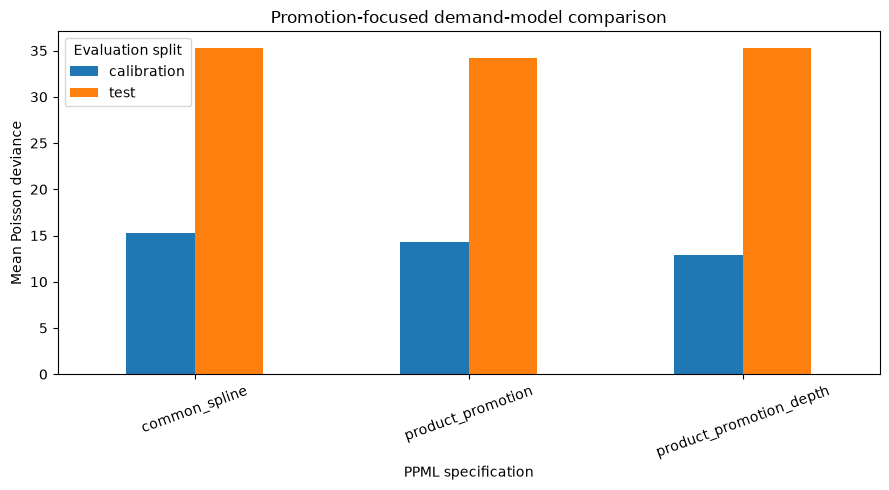

Saved: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\figures\promotion_model_comparison.png


In [104]:
plot_data = overall_metrics.pivot(
    index="model",
    columns="split",
    values="mean_poisson_deviance",
).reindex(PPML_MODELS)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data.plot(kind="bar", ax=ax)

ax.set_xlabel("PPML specification")
ax.set_ylabel("Mean Poisson deviance")
ax.set_title(
    "Promotion-focused demand-model comparison"
)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Evaluation split")

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "promotion_model_comparison.png"
)
fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Saved: {figure_path}")

In [107]:
import numpy as np
import statsmodels.api as sm

model_a = "product_promotion_depth"
model_b = "product_promotion"

weekly_deviance = (
    predictions.loc[
        predictions["split"].eq("test")
        & predictions["model"].isin([model_a, model_b]),
        ["week", "model", "poisson_deviance"],
    ]
    .pivot_table(
        index="week",
        columns="model",
        values="poisson_deviance",
        aggfunc="mean",
    )
    .dropna()
    .sort_index()
)

loss_difference = (
    weekly_deviance[model_a] - weekly_deviance[model_b]
)

comparison_fit = sm.OLS(
    loss_difference.to_numpy(),
    np.ones((len(loss_difference), 1)),
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": min(4, len(loss_difference) - 1)},
)

print("Weeks compared:", len(loss_difference))
print(
    "Mean deviance difference "
    "(depth − product promotion):",
    loss_difference.mean(),
)
print("HAC SE:", comparison_fit.bse[0])
print("t statistic:", comparison_fit.tvalues[0])
print("p value:", comparison_fit.pvalues[0])
print("95% CI:", comparison_fit.conf_int()[0])

Weeks compared: 70
Mean deviance difference (depth − product promotion): 1.1309501082443176
HAC SE: 1.4509303534387912
t statistic: 0.7794654688723681
p value: 0.43570557115457553
95% CI: [-1.71282113  3.97472135]


In [108]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

MODEL_A = "product_promotion_depth"
MODEL_B = "product_promotion"
HAC_MAX_LAGS = 4

# Never use these test results to change the calibration-selected model.
evaluation_predictions = predictions.loc[
    predictions["split"].eq("test")
].copy()

evaluation_predictions["promotion_state"] = np.select(
    [
        evaluation_predictions["promotion_indicator"].eq(1),
        evaluation_predictions["post_promotion_indicator"].eq(1),
    ],
    ["promotion", "post_promotion"],
    default="regular",
)
comparison_rows = []
weekly_loss_differences = {}

for comparison_label, comparison_frame in {
    "all test observations": evaluation_predictions,
    "promotion rows": evaluation_predictions.loc[
        evaluation_predictions["promotion_state"].eq("promotion")
    ],
    "regular rows": evaluation_predictions.loc[
        evaluation_predictions["promotion_state"].eq("regular")
    ],
    "post-promotion rows": evaluation_predictions.loc[
        evaluation_predictions["promotion_state"].eq("post_promotion")
    ],
}.items():
    summary, _, difference = paired_weekly_loss_test(
        comparison_frame,
        model_a=MODEL_A, model_b=MODEL_B, label=comparison_label,
        max_lags=HAC_MAX_LAGS,
    )
    comparison_rows.append(summary)
    weekly_loss_differences[comparison_label] = difference

loss_comparisons = pd.DataFrame(comparison_rows)

display(
    loss_comparisons.style.format(
        {
            "mean_deviance_difference": "{:.4f}",
            "hac_se": "{:.4f}",
            "t_statistic": "{:.3f}",
            "p_value": "{:.3f}",
            "ci_lower": "{:.4f}",
            "ci_upper": "{:.4f}",
        }
    )
)

print(
    f"Difference definition: {MODEL_A} − {MODEL_B}. "
    "Negative values favour the depth model."
)

,comparison,weeks,mean_deviance_difference,hac_se,t_statistic,p_value,ci_lower,ci_upper
0,all test observations,70,1.1310,1.4509,0.779,0.436,-1.7128,3.9747
1,promotion rows,67,3.3724,5.4983,0.613,0.540,-7.4041,14.1490
2,regular rows,70,-0.2293,0.4146,-0.553,0.580,-1.0418,0.5832
3,post-promotion rows,62,-1.5942,0.4390,-3.632,0.000,-2.4546,-0.7338


Difference definition: product_promotion_depth − product_promotion. Negative values favour the depth model.


## 15. Export of the selected specification

The selected rolling specification is held fixed for all downstream analyses. This section exports row-level predictions, model metadata, temporal-split information, and the variables required to reproduce the non-promotional baseline.

In [116]:
MODEL_DIR = PROJECT_ROOT / "results" / "models"

ROLLING_MODEL_DIR = (
    MODEL_DIR / "product_promotion_rolling_ppml"
)

ROLLING_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ROLLING_MANIFEST_PATH = (
    DEMAND_ARTIFACT_DIR
    / "demand_model_manifest.pkl"
)

PREDICTION_CONTEXT_PATH = (
    DEMAND_ARTIFACT_DIR
    / "demand_prediction_context.pkl"
)

POLICY_PREDICTION_PATH = (
    DEMAND_ARTIFACT_DIR / "policy_common_origin_predictions.pkl"
)

SELECTED_MODEL_NAME = selected_model

In [118]:
rolling_manifest = export_rolling_ppml_models(
    model_data=model_data,
    forecast_weeks=forecast_weeks,
    model_name=SELECTED_MODEL_NAME,
    output_dir=ROLLING_MODEL_DIR,
    refit_every_n_weeks=REFIT_EVERY_N_WEEKS,
    common_controls=DEFAULT_COMMON_CONTROLS,
)

if rolling_manifest.empty:
    raise RuntimeError("No rolling PPML artifacts were created.")

display(rolling_manifest)

,model,block_number,first_forecast_week,last_forecast_week,fit_last_week,spline_lower,spline_upper,model_filename,converged
0,product_promotion_depth,0,220,223,218,-0.063362,1.383791,product_promotion_depth_block_000.npz,True
1,product_promotion_depth,1,224,227,223,-0.010050,1.383791,product_promotion_depth_block_001.npz,True
2,product_promotion_depth,2,228,231,227,-0.010050,1.403643,product_promotion_depth_block_002.npz,True
3,product_promotion_depth,3,232,235,231,-0.010050,1.403643,product_promotion_depth_block_003.npz,True
4,product_promotion_depth,4,236,239,235,-0.010050,1.403643,product_promotion_depth_block_004.npz,True
5,product_promotion_depth,5,240,243,239,-0.010050,1.418277,product_promotion_depth_block_005.npz,True
6,product_promotion_depth,6,244,247,243,-0.010050,1.456287,product_promotion_depth_block_006.npz,True
7,product_promotion_depth,7,248,251,247,-0.010050,1.456287,product_promotion_depth_block_007.npz,True
8,product_promotion_depth,8,252,255,251,-0.010050,1.456287,product_promotion_depth_block_008.npz,True
9,product_promotion_depth,9,256,259,255,-0.010050,1.456287,product_promotion_depth_block_009.npz,True


In [119]:
rolling_manifest.to_pickle(
    ROLLING_MANIFEST_PATH
)

context_columns = [
    "store_upc",
    "upc",
    "week",
    "calendar_month",
    "scaled_time_trend",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "log1p_lag_move",
    "log1p_lag_move_mean_4",
    "price_imputed_indicator",
    "promotion_indicator",
    "post_promotion_indicator",
]

prediction_context = (
    model_data.loc[
        model_data["week"].isin(
            forecast_weeks
        ),
        context_columns,
    ]
    .copy()
    .drop_duplicates(
        ["store_upc", "week"]
    )
    .sort_values(
        ["week", "store_upc"]
    )
    .reset_index(drop=True)
)

if prediction_context.duplicated(
    ["store_upc", "week"]
).any():
    raise ValueError(
        "Prediction context contains duplicate panel-weeks."
    )

prediction_context.to_pickle(
    PREDICTION_CONTEXT_PATH
)

In [120]:
print(
    "Saved manifest:",
    ROLLING_MANIFEST_PATH,
)

POLICY_FORECAST_WEEKS = np.asarray(test_weeks, dtype=int)
POLICY_ORIGIN_WEEK = int(POLICY_FORECAST_WEEKS.min())
policy_predictions = common_origin_ex_ante_predictions(
    frame=policy_model_data,
    forecast_week_values=POLICY_FORECAST_WEEKS,
    model_name=SELECTED_MODEL_NAME,
    planning_origin_week=POLICY_ORIGIN_WEEK,
    common_controls=POLICY_COMMON_CONTROLS,
)
policy_predictions["split"] = "test"
if not policy_predictions["origin_predictors_verified"].all():
    raise AssertionError("Policy profile contains a non-origin predictor.")
policy_predictions.to_pickle(POLICY_PREDICTION_PATH)

if policy_predictions["fit_last_week"].nunique() != 1:
    raise AssertionError("Policy forecasts must use one common-origin fit.")
if int(policy_predictions["fit_last_week"].max()) >= POLICY_ORIGIN_WEEK:
    raise AssertionError("Policy fit uses outcomes from its forecast horizon.")

print("Saved common-origin policy forecasts:", POLICY_PREDICTION_PATH)

print(
    "Saved prediction context:",
    PREDICTION_CONTEXT_PATH,
)

display(rolling_manifest)

Saved manifest: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\demand\demand_model_manifest.pkl
Saved common-origin policy forecasts: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\demand\policy_common_origin_predictions.pkl
Saved prediction context: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\demand\demand_prediction_context.pkl


,model,block_number,first_forecast_week,last_forecast_week,fit_last_week,spline_lower,spline_upper,model_filename,converged
0,product_promotion_depth,0,220,223,218,-0.063362,1.383791,product_promotion_depth_block_000.npz,True
1,product_promotion_depth,1,224,227,223,-0.010050,1.383791,product_promotion_depth_block_001.npz,True
2,product_promotion_depth,2,228,231,227,-0.010050,1.403643,product_promotion_depth_block_002.npz,True
3,product_promotion_depth,3,232,235,231,-0.010050,1.403643,product_promotion_depth_block_003.npz,True
4,product_promotion_depth,4,236,239,235,-0.010050,1.403643,product_promotion_depth_block_004.npz,True
5,product_promotion_depth,5,240,243,239,-0.010050,1.418277,product_promotion_depth_block_005.npz,True
6,product_promotion_depth,6,244,247,243,-0.010050,1.456287,product_promotion_depth_block_006.npz,True
7,product_promotion_depth,7,248,251,247,-0.010050,1.456287,product_promotion_depth_block_007.npz,True
8,product_promotion_depth,8,252,255,251,-0.010050,1.456287,product_promotion_depth_block_008.npz,True
9,product_promotion_depth,9,256,259,255,-0.010050,1.456287,product_promotion_depth_block_009.npz,True


## 16. Save reproducibility and model-comparison outputs

In [113]:
prediction_path = (
    DEMAND_ARTIFACT_DIR
    / "demand_predictions.pkl"
)

metrics_path = (
    TABLE_DIR
    / "final_demand_model_comparison.csv"
)

promotion_path = (
    TABLE_DIR
    / "final_demand_model_by_promotion_state.csv"
)

counterfactual_audit_path = (
    TABLE_DIR / "ppml_regular_counterfactual_audit.csv"
)

product_selection_path = (
    TABLE_DIR
    / "product_selection_table.csv"
)

product_flow_path = (
    TABLE_DIR
    / "product_selection_flow.csv"
)

store_selection_path = (
    TABLE_DIR
    / "store_selection_table.csv"
)

panel_selection_path = (
    TABLE_DIR
    / "panel_selection_table.csv"
)

selected_products_path = (
    TABLE_DIR
    / "selected_products.csv"
)

predictions.to_pickle(prediction_path)

counterfactual_audit = regular_counterfactual_audit(
    predictions,
    model_name=SELECTED_MODEL_NAME,
)
counterfactual_audit.to_csv(
    counterfactual_audit_path,
    index=False,
)

overall_metrics.to_csv(metrics_path, index=False)

promotion_metrics.to_csv(
    promotion_path,
    index=False,
)

product_selection.to_csv(
    product_selection_path,
    index=False,
)

product_selection_flow.to_csv(
    product_flow_path,
    index=False,
)

In [114]:
store_selection.to_csv(
    store_selection_path,
    index=False,
)

panel_selection.to_csv(
    panel_selection_path,
    index=False,
)

pd.DataFrame(
    {"upc": selected_upcs}
).to_csv(
    selected_products_path,
    index=False,
)

print(f"Saved predictions: {prediction_path}")
print(f"Saved counterfactual audit: {counterfactual_audit_path}")

print(f"Saved metrics: {metrics_path}")

print(f"Saved promotion diagnostics: {promotion_path}")

print(f"Saved product selection: {product_selection_path}")

print(f"Saved product flow: {product_flow_path}")

print(f"Saved store selection: {store_selection_path}")

print(f"Saved panel selection: {panel_selection_path}")

print(f"Saved selected UPCs: {selected_products_path}")

Saved predictions: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\demand\demand_predictions.pkl
Saved counterfactual audit: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\ppml_regular_counterfactual_audit.csv
Saved metrics: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\final_demand_model_comparison.csv
Saved promotion diagnostics: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\final_demand_model_by_promotion_state.csv
Saved product selection: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\product_selection_table.csv
Saved product flow: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\product_selection_flow.csv
Saved store selection: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\ta